In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("flight_modified.csv")

## Data Understanding

In [5]:
df.head()

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,18.0,711,707,-4.0,0,0,0,187.0,8.0,0.0,0.0,0,0,1
1,6,NaN,600,554,22.0,711,703,-8.0,0,0,0,187.0,13.0,0.0,NaN,0,0,1
2,1,BOS,600,601,1.0,711,706,NaN,0,0,0,187.0,6.0,NaN,NaN,0,0,1
3,2,BOS,600,556,-4.0,711,709,NaN,0,0,0,187.0,0.0,0.0,0.0,0,0,1
4,3,BOS,600,552,-8.0,711,659,-12.0,0,0,0,NaN,4.0,0.0,0.0,0,0,1


In [6]:
df.tail()

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
4816,4,LAX,815,845,30.0,1652,1728,36.0,1,0,0,2611.0,8.0,8.0,NaN,0,0,1
4817,5,LAX,815,811,24.0,1652,1626,-26.0,0,0,0,2611.0,18.0,12.0,0.0,0,0,1
4818,7,LAX,815,809,-6.0,1652,1619,-33.0,0,0,0,2611.0,0.0,37.0,0.0,0,0,1
4819,1,LAX,815,811,-4.0,1652,1709,17.0,1,0,0,2611.0,0.0,5.0,17.0,0,0,1
4820,2,LAX,815,945,90.0,1652,1819,87.0,1,0,0,2611.0,36.0,9.0,0.0,0,0,1


In [7]:
df.shape

(4821, 18)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4821 entries, 0 to 4820
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DayOfWeek            4821 non-null   int64  
 1   Origin_Airport       4629 non-null   object 
 2   Scheduled_Departure  4821 non-null   int64  
 3   Departure_Time       4821 non-null   int64  
 4   Dep_Delay            4561 non-null   float64
 5   Scheduled_Arrival    4821 non-null   int64  
 6   Arrival_Time         4821 non-null   int64  
 7   Arrival_Delay        4438 non-null   float64
 8   Arr_Del_morethan15   4821 non-null   int64  
 9   Cancelled            4821 non-null   int64  
 10  Diverted             4821 non-null   int64  
 11  Distance             4436 non-null   float64
 12  Carrier_Delay        4801 non-null   float64
 13  WeatherDelay         4603 non-null   float64
 14  NAS_Delay            4474 non-null   float64
 15  Security_Delay       4821 non-null   i

In [10]:
df.columns

Index(['DayOfWeek', 'Origin_Airport', 'Scheduled_Departure', 'Departure_Time',
       'Dep_Delay', 'Scheduled_Arrival', 'Arrival_Time', 'Arrival_Delay',
       'Arr_Del_morethan15', 'Cancelled', 'Diverted', 'Distance',
       'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay',
       'Late_Aircraft_Delay', 'Top_Carriers'],
      dtype='object')

In [11]:
df.size

86778

In [12]:
df.describe()

,DayOfWeek,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
count,4821.000000,4821.000000,4821.000000,4561.000000,4821.000000,4821.000000,4438.000000,4821.000000,4821.000000,4821.0,4436.000000,4801.000000,4603.000000,4474.000000,4821.000000,4821.000000,4821.0
mean,4.153703,1338.688032,1335.738021,36.030695,1502.412777,1468.282099,24.011492,0.322132,0.019498,0.0,1540.515780,13.407415,11.047360,10.186634,0.051442,8.968056,1.0
std,2.007099,495.435065,524.024009,120.731783,562.241023,600.535851,106.182684,0.467342,0.138282,0.0,920.889678,41.084129,23.188351,26.588018,1.524846,39.956099,0.0
min,1.000000,40.000000,1.000000,-20.000000,5.000000,1.000000,-58.000000,0.000000,0.000000,0.0,-497.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,2.000000,900.000000,857.000000,-2.000000,1131.000000,1053.000000,-11.000000,0.000000,0.000000,0.0,740.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,4.000000,1335.000000,1334.000000,11.000000,1549.000000,1538.000000,1.000000,0.000000,0.000000,0.0,1438.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,6.000000,1725.000000,1751.000000,29.000000,1937.000000,1943.000000,25.000000,1.000000,0.000000,0.0,2475.000000,12.000000,21.000000,9.000000,0.000000,0.000000,1.0
max,7.000000,2357.000000,2400.000000,1498.000000,2359.000000,2400.000000,1869.000000,1.000000,1.000000,0.0,3784.000000,532.000000,1010.000000,359.000000,68.000000,1333.000000,1.0


In [13]:
df.describe(include="object")

,Origin_Airport
count,4629
unique,18
top,LAX
freq,1007


In [14]:
df.isnull().sum()

DayOfWeek                0
Origin_Airport         192
Scheduled_Departure      0
Departure_Time           0
Dep_Delay              260
Scheduled_Arrival        0
Arrival_Time             0
Arrival_Delay          383
Arr_Del_morethan15       0
Cancelled                0
Diverted                 0
Distance               385
Carrier_Delay           20
WeatherDelay           218
NAS_Delay              347
Security_Delay           0
Late_Aircraft_Delay      0
Top_Carriers             0
dtype: int64

In [15]:
df.isnull().mean()

DayOfWeek              0.000000
Origin_Airport         0.039826
Scheduled_Departure    0.000000
Departure_Time         0.000000
Dep_Delay              0.053931
Scheduled_Arrival      0.000000
Arrival_Time           0.000000
Arrival_Delay          0.079444
Arr_Del_morethan15     0.000000
Cancelled              0.000000
Diverted               0.000000
Distance               0.079859
Carrier_Delay          0.004149
WeatherDelay           0.045219
NAS_Delay              0.071977
Security_Delay         0.000000
Late_Aircraft_Delay    0.000000
Top_Carriers           0.000000
dtype: float64

In [17]:
df.duplicated().sum()

np.int64(0)

## Univariate Analysis

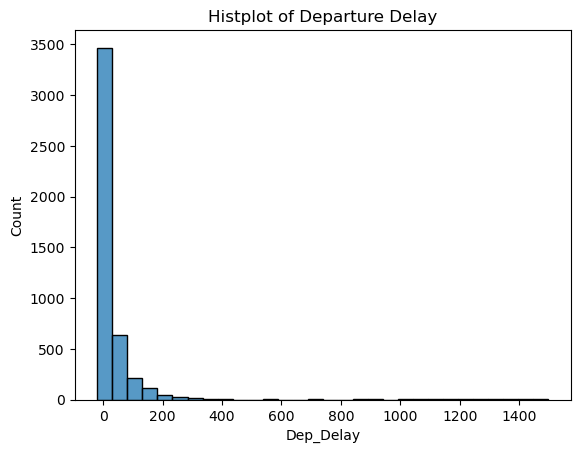

In [22]:
sns.histplot(df["Dep_Delay"],bins=30)
plt.title("Histplot of Departure Delay")
plt.show()

#### Most passengers reach close to the scheduled departure time. However, a few flights experience significant delays, which stretch the distribution toward higher delay values.

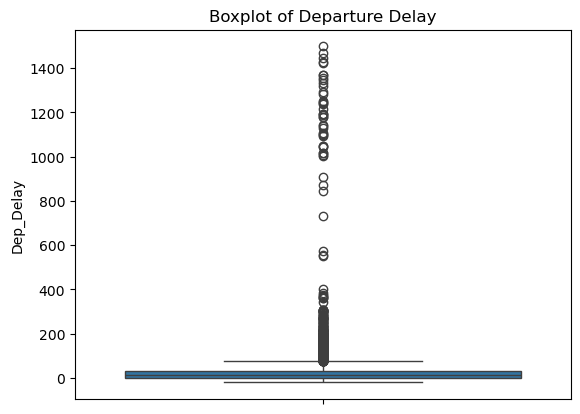

In [26]:
sns.boxplot(df["Dep_Delay"])
plt.title("Boxplot of Departure Delay")
plt.show()

#### Although the majority of flights depart on time or with small delays, there are several extreme delay cases. These unusual flights deserve further investigation because they may be caused by weather, technical issues, or airport congestion.

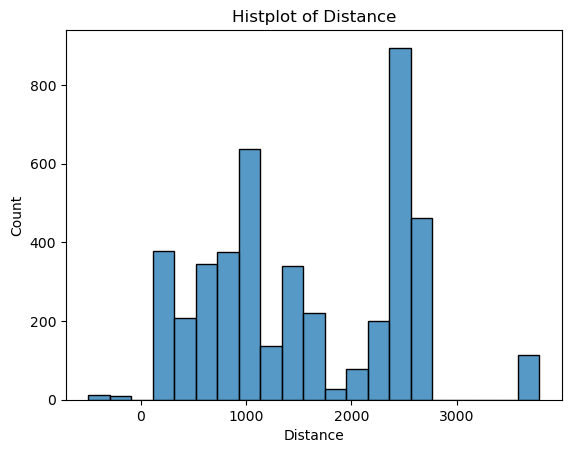

In [27]:
sns.histplot(df["Distance"])
plt.title("Histplot of Distance")
plt.show()

#### Airlines operate a much larger number of short and medium-haul flights compared to long-haul routes, resulting in a right-skewed distance distribution.

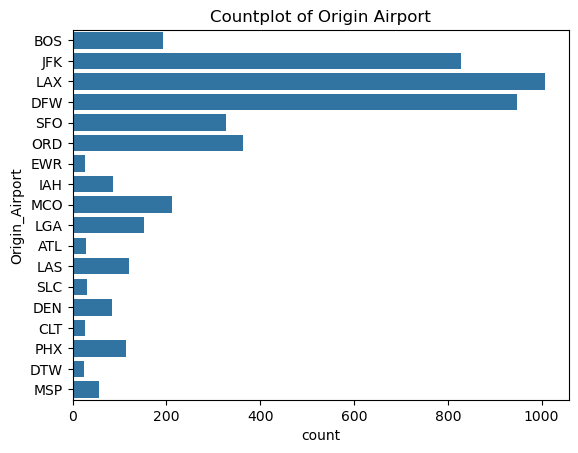

In [29]:
sns.countplot(data=df, y="Origin_Airport")
plt.title("Countplot of Origin Airport")
plt.show()

#### Flight operations are concentrated at a few major airports, while smaller airports contribute much fewer flights.

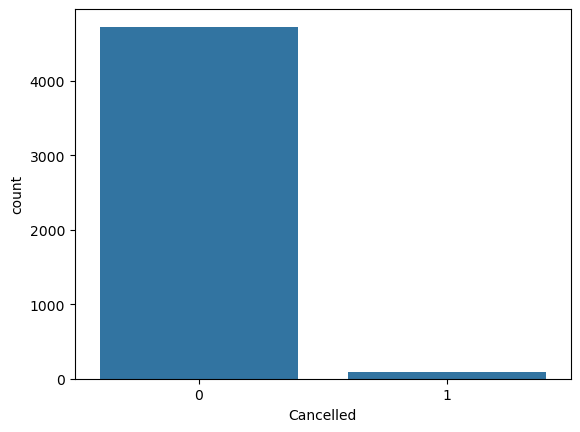

In [31]:
sns.countplot(data=df, x= "Cancelled")
plt.show()

#### Only a small proportion of flights are cancelled, indicating that cancellations are relatively rare compared to successfully operated flights.

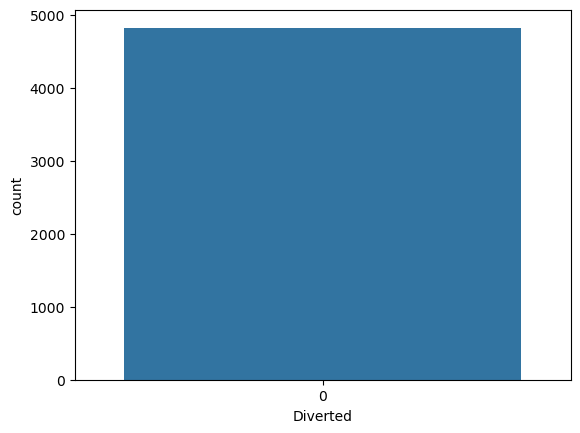

In [32]:
sns.countplot(data=df, x="Diverted")
plt.show()

#### Flight diversions are uncommon, suggesting that most flights reach their intended destinations without needing to divert.

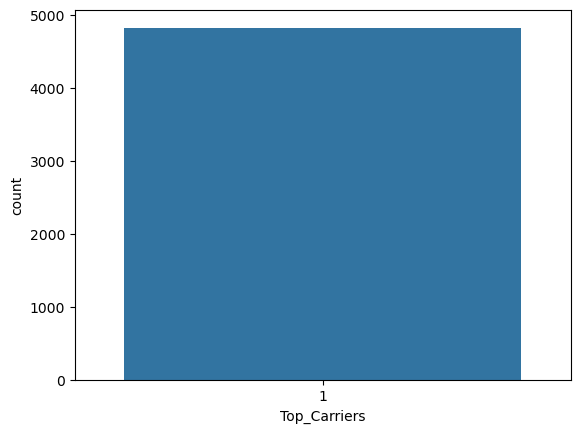

In [33]:
sns.countplot(data=df, x="Top_Carriers")
plt.show()

#### Some airlines contribute significantly more flights than others. This difference should be considered before comparing average delays because airlines with more flights naturally generate more observations.

## Bivariate Analysis

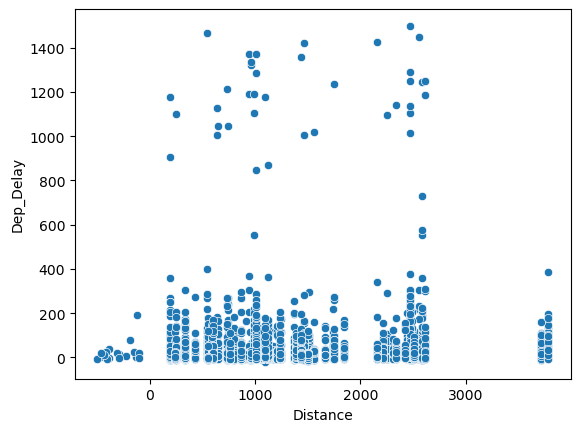

In [34]:
sns.scatterplot(x="Distance",y="Dep_Delay",data=df)
plt.show()

#### There is no strong relationship between flight distance and departure delay. Both short and long-distance flights experience delays, suggesting that departure delays are influenced more by operational factors than by route length.

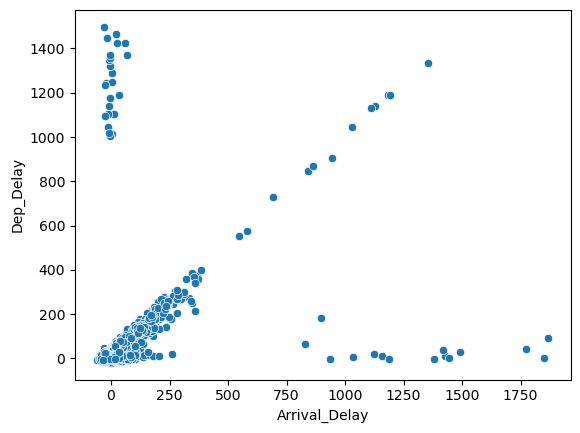

In [36]:
sns.scatterplot(x="Arrival_Delay",y="Dep_Delay",data=df)
plt.show()

#### A clear positive relationship exists between departure delay and arrival delay. Flights that depart late usually arrive late as well, although some flights recover part of the lost time during the journey.

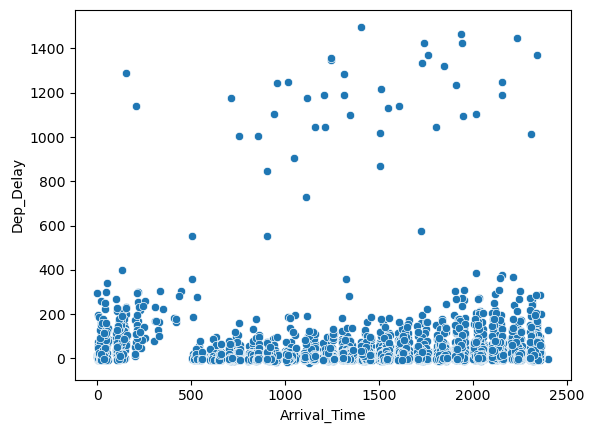

In [37]:
sns.scatterplot(x="Arrival_Time",y="Dep_Delay",data=df)
plt.show()

#### Departure delays occur across different arrival times without a clear trend, indicating that arrival time alone is not a strong predictor of departure delay.

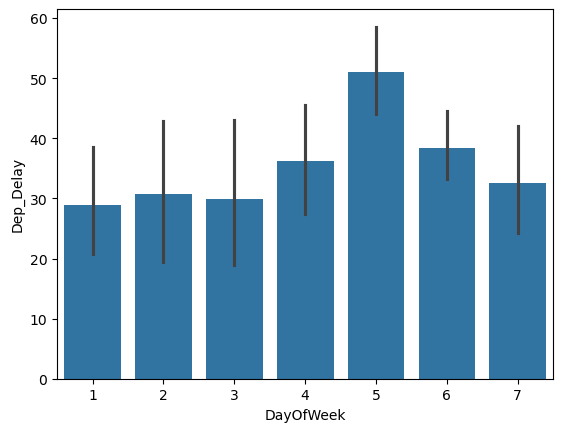

In [35]:
sns.barplot(x="DayOfWeek",y="Dep_Delay",data=df)
plt.show()

#### Average departure delay varies slightly across different days of the week. Certain days appear to experience higher delays, which may be due to increased passenger traffic or operational workload

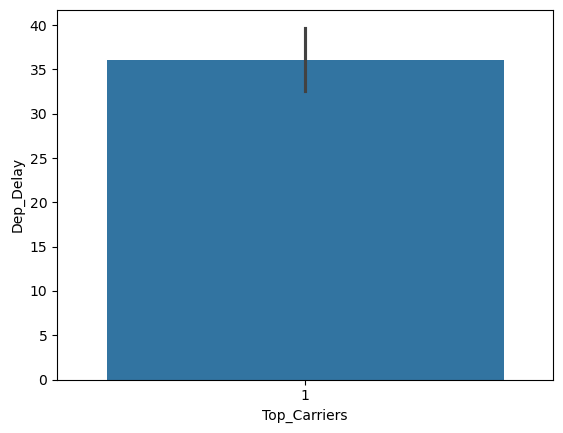

In [38]:
sns.barplot(data=df, x="Top_Carriers", y="Dep_Delay")
plt.show()

#### Average delays differ between airlines. Some carriers consistently perform better than others, indicating differences in operational efficiency and schedule management.

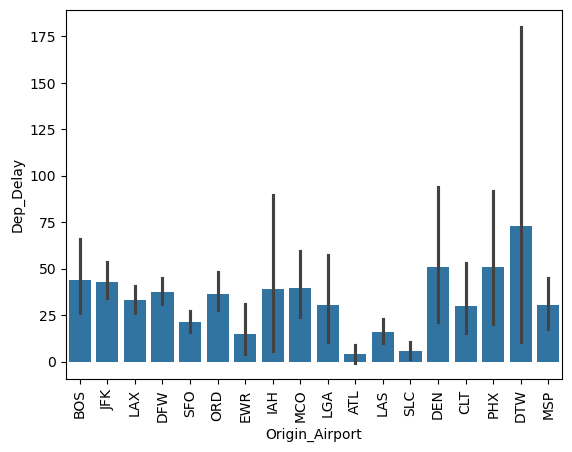

In [39]:
sns.barplot(data=df, x="Origin_Airport", y="Dep_Delay")
plt.xticks(rotation=90)
plt.show()

#### Certain airports have noticeably higher average departure delays than others. Airport congestion, runway capacity, and weather conditions may contribute to these differences.

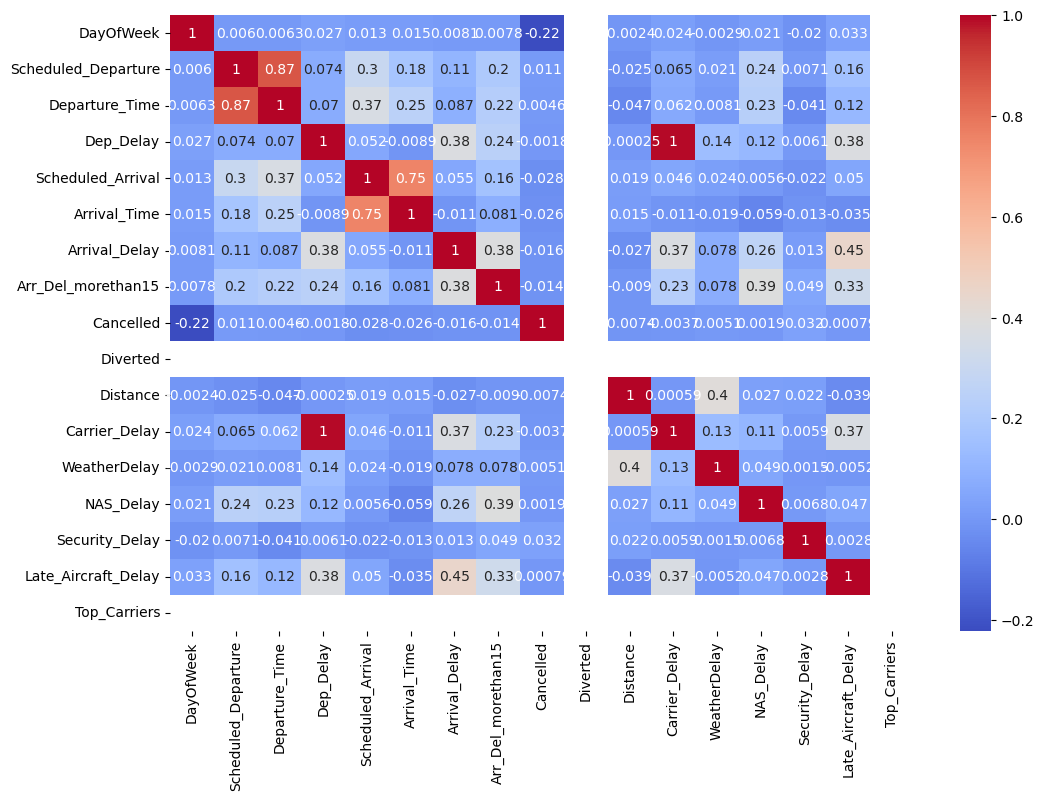

In [41]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

#### Most numerical variables show weak correlations. However, Arrival Delay and Departure Delay exhibit a strong positive correlation, indicating that late departures frequently lead to late arrivals.

## Final Findings
- #### Most flights depart on time.
- #### Few flights experience very high delays.
- #### Departure delay strongly affects arrival delay.
- #### Distance has little effect on departure delay.
- #### Some airlines consistently experience higher delays.
- #### Certain airports are more delay-prone.
- #### Flight cancellations and diversions are relatively rare.